# 1 create motif enrichment graph for whole embryo dataset, figure 2

In [1]:
file_dir = '/staging/leuven/stg_00171/Mark/IX_XII_MP_integration/paper_subsets/scenicplus_G/'

In [2]:
import pandas as pd
import h5py
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

ctx = pd.read_html(file_dir + 'ctx_results_G.html', header=0)

In [3]:
ctx = ctx[0]

In [4]:
topic_22 = ctx[ctx['Region_set'].isin(['Topics_top_2k_Topic22'])]
topic_10 = ctx[ctx['Region_set'].isin(['Topics_top_2k_Topic10'])]
topic_29 = ctx[ctx['Region_set'].isin(['Topics_top_2k_Topic29'])]
topic_8 = ctx[ctx['Region_set'].isin(['Topics_top_2k_Topic8'])]

In [7]:
 ctx[ctx['Direct_annot'].isin(['OctVul6B013567'])]

,Unnamed: 0,Logo,Region_set,NES,AUC,Rank_at_max,Direct_annot,Orthology_annot,Motif_hits
1927,nitta__scro_TTGGGA20NTA_KH_NCACTYNAC_m1_c3,NaN,Topics_otsu_Topic14,2.047327,0.001004,56,OctVul6B013567,NaN,6
10539,nitta__scro_TTGGGA20NTA_KH_NCACTYNAC_m1_c3,NaN,Topics_otsu_Topic7,2.092948,0.001795,49785,OctVul6B013567,NaN,1766
13937,nitta__scro_TTGGGA20NTA_KH_NCACTYNAC_m1_c3,NaN,Topics_otsu_Topic13,2.357536,0.001963,47748,OctVul6B013567,NaN,1451
19066,nitta__scro_TTGGGA20NTA_KH_NCACTYNAC_m1_c3,NaN,Topics_top_2k_Topic34,2.415550,0.003118,78356,OctVul6B013567,NaN,799
25348,nitta__scro_TTGGGA20NTA_KH_NCACTYNAC_m1_c3,NaN,Topics_top_2k_Topic7,3.195801,0.005009,49738,OctVul6B013567,NaN,463


In [21]:
topic_22_top = topic_22.head(100)
topic_10_top = topic_10.head(100)
topic_29_top = topic_29.head(100)
topic_8_top = topic_8.head(100)

In [23]:
shared = topic_22_top.merge(topic_8_top, how='inner', left_on='Unnamed: 0', right_on='Unnamed: 0')
len(shared)

8

In [24]:
top_22 = topic_22_top[['Unnamed: 0', 'Region_set', 'NES']]
top_10 = topic_10_top[['Unnamed: 0', 'Region_set', 'NES']]
top_29 = topic_29_top[['Unnamed: 0', 'Region_set', 'NES']]
top_8 = topic_8_top[['Unnamed: 0', 'Region_set', 'NES']]


In [25]:
top = pd.concat([top_22, top_10, top_29, top_8])

In [53]:
heatmap_df = top.pivot(
    index="Unnamed: 0",
    columns="Region_set",
    values="NES"
)

In [54]:
heatmap_df = heatmap_df[['Topics_top_2k_Topic22', 'Topics_top_2k_Topic10', 'Topics_top_2k_Topic29', 'Topics_top_2k_Topic8']]

In [57]:
specificity = heatmap_df.idxmax(axis=1)

In [58]:
specificity

Unnamed: 0
c2h2_zfs__M0436            Topics_top_2k_Topic8
cisbp__M00017             Topics_top_2k_Topic29
cisbp__M00029             Topics_top_2k_Topic29
cisbp__M00056              Topics_top_2k_Topic8
cisbp__M00070             Topics_top_2k_Topic10
                                  ...          
yetfasco__YDL056W_2138     Topics_top_2k_Topic8
yetfasco__YER184C_2095    Topics_top_2k_Topic22
yetfasco__YGL073W_1461     Topics_top_2k_Topic8
yetfasco__YMR182C_531      Topics_top_2k_Topic8
yetfasco__YPL230W_509      Topics_top_2k_Topic8
Length: 357, dtype: object

In [59]:
row_order = (
    specificity
    .sort_values()
    .index
)

heatmap_df = heatmap_df.loc[row_order]

In [60]:
heatmap_df = heatmap_df.T

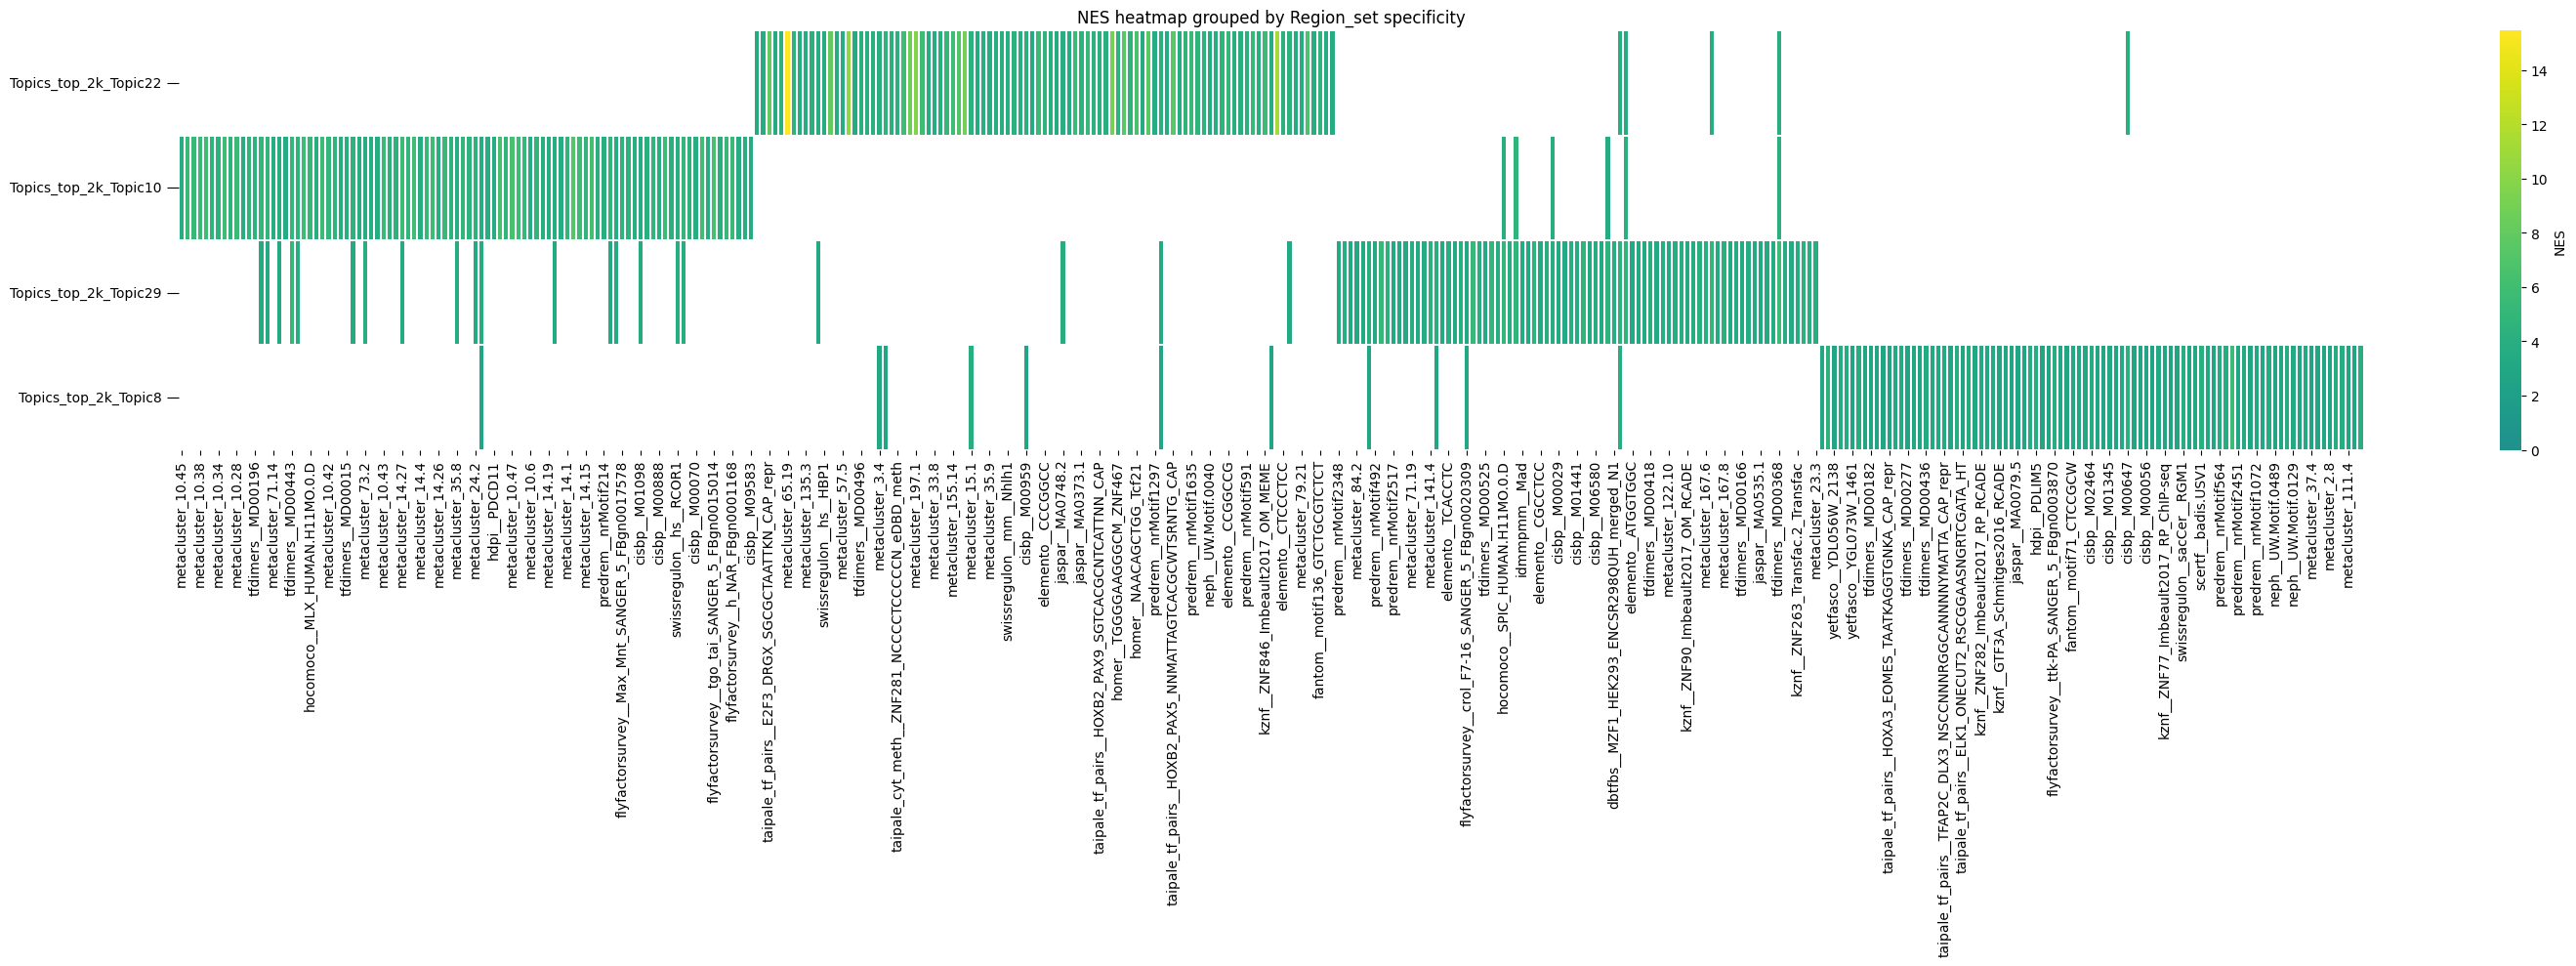

In [61]:
plt.figure(figsize=(30, 10))

vmax = heatmap_df.max().max()

sns.heatmap(
    heatmap_df,
    cmap="viridis",
    center=0,
    linewidths=0.3,
    cbar_kws={"label": "NES"},
    vmin=0,
    vmax=vmax
)

plt.tick_params(axis='y',
    rotation=0,
    size=9
               )

plt.xlabel("")
plt.ylabel("")
plt.title("NES heatmap grouped by Region_set specificity")
plt.tight_layout()
plt.savefig('figures/paper/Figure 2/NES_motifs_Top22_10_29_8.pdf', dpi=300)
plt.show()


# 2 create motif enrichment graph for glia subset, figure 3

In [1]:
file_dir = '/staging/leuven/stg_00171/Mark/IX_XII_MP_integration/paper_subsets/scenicplus_G/'

In [2]:
import pandas as pd
import h5py
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

ctx = pd.read_html(file_dir + 'ctx_results_G.html', header=0)

In [3]:
ctx = ctx[0]

In [ ]:
top_1 = topic_1_top[['Unnamed: 0', 'Region_set', 'NES']]
top_2 = topic_2_top[['Unnamed: 0', 'Region_set', 'NES']]
top_4 = topic_4_top[['Unnamed: 0', 'Region_set', 'NES']]
top_7 = topic_7_top[['Unnamed: 0', 'Region_set', 'NES']]
top_8 = topic_8_top[['Unnamed: 0', 'Region_set', 'NES']]


In [15]:
top = pd.concat([top_4, top_8, top_7, top_2, top_1])

In [53]:
heatmap_df = top.pivot(
    index="Unnamed: 0",
    columns="Region_set",
    values="NES"
)

In [39]:
specificity = heatmap_df.idxmax(axis=1)


In [45]:
topic_order = [
    "Topics_otsu_Topic4",
    "Topics_otsu_Topic8",
    "Topics_otsu_Topic7",
    "Topics_otsu_Topic2",
    "Topics_otsu_Topic1",
]

# convert to ordered categorical
s_cat = pd.Categorical(
    specificity,
    categories=topic_order,
    ordered=True
)

# sort and keep the original index
s_sorted = specificity.iloc[s_cat.argsort()]

In [54]:
row_order = (
    s_sorted.index
)

heatmap_df = heatmap_df.loc[row_order]

In [55]:
heatmap_df = heatmap_df.T

In [58]:
heatmap_df = heatmap_df.loc[topic_order]

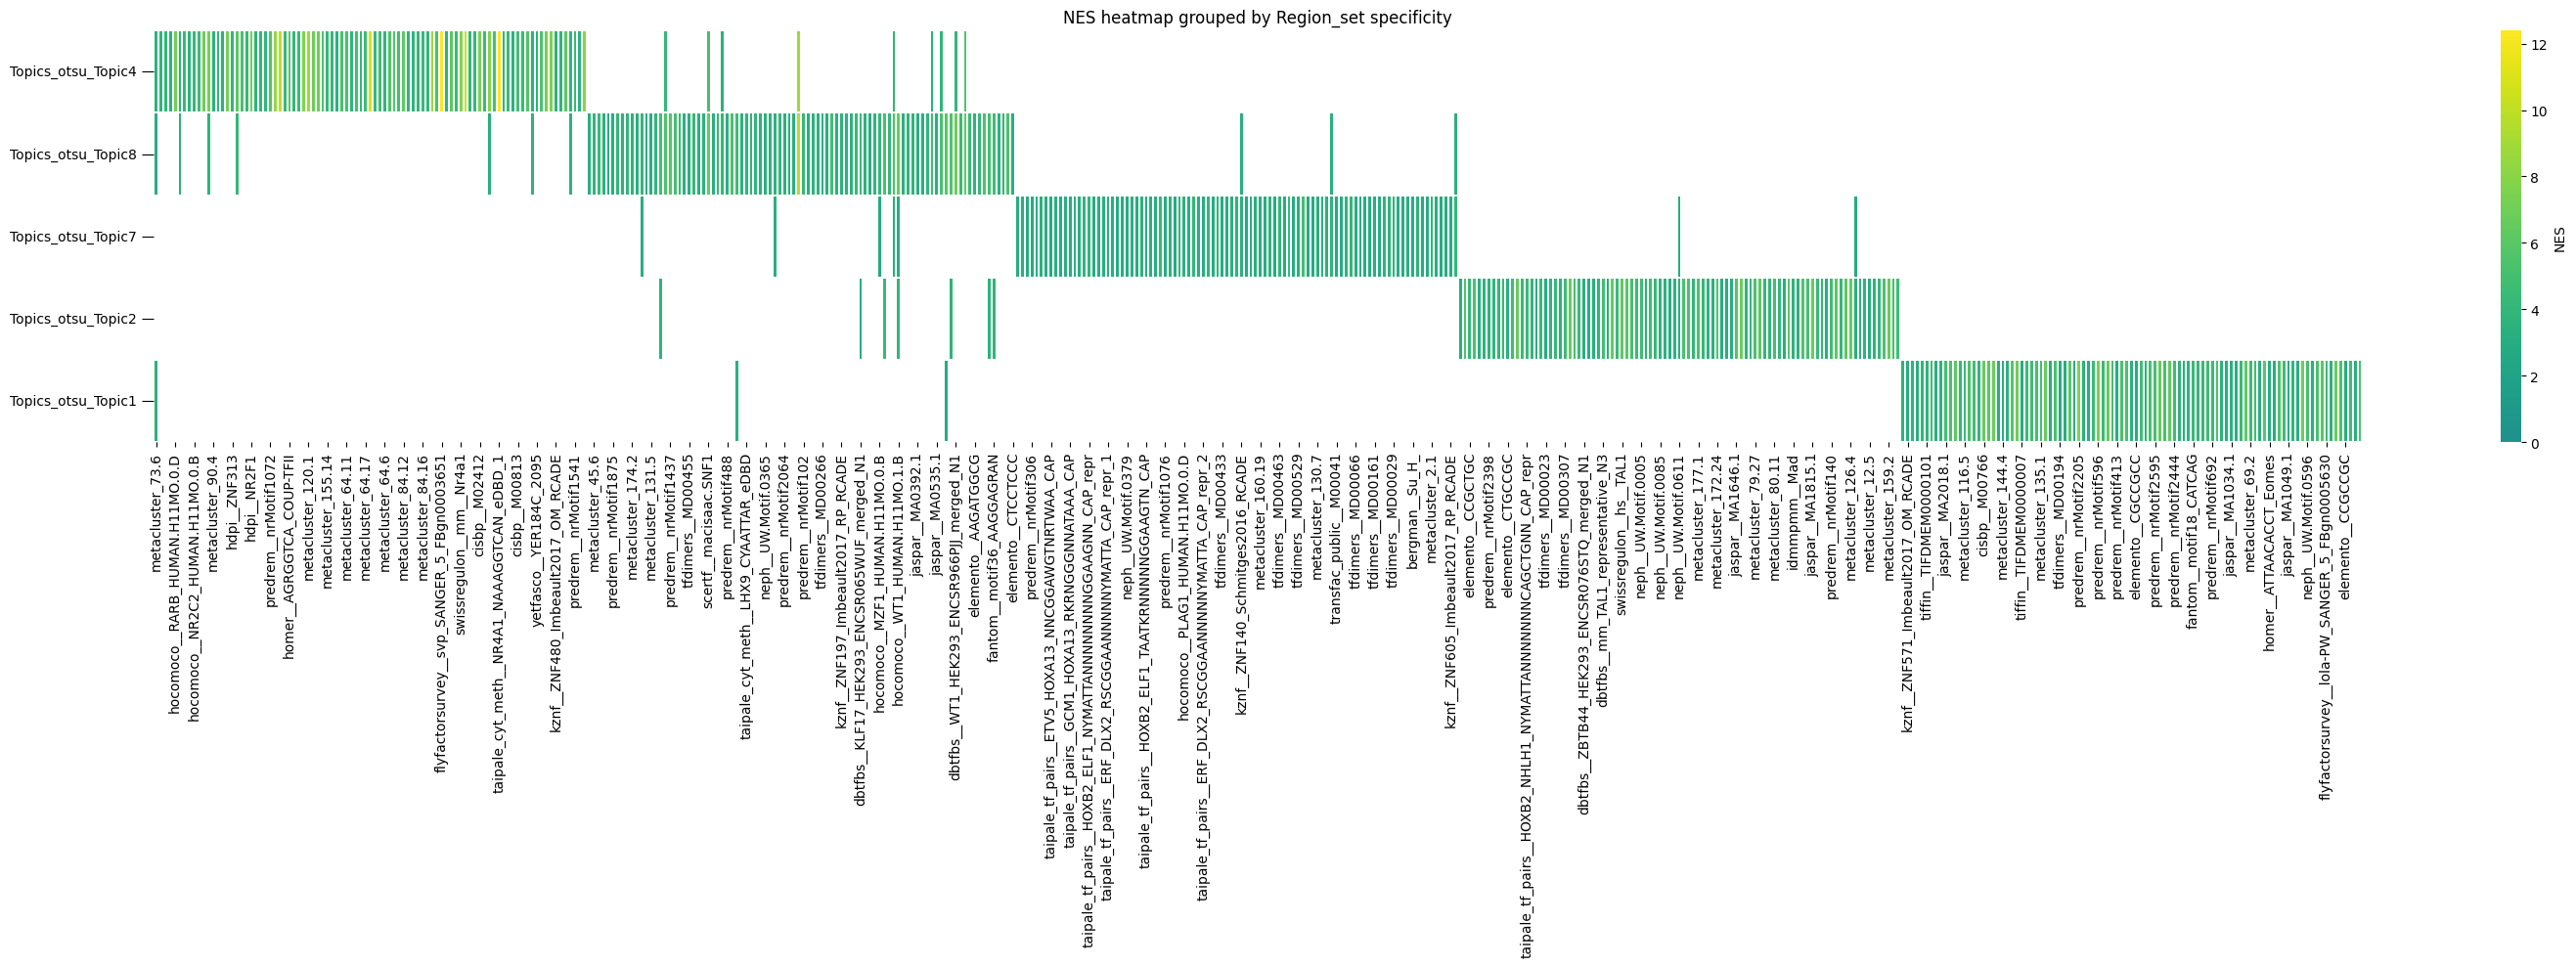

In [60]:
plt.figure(figsize=(30, 10))

vmax = heatmap_df.max().max()

sns.heatmap(
    heatmap_df,
    cmap="viridis",
    center=0,
    linewidths=0.3,
    cbar_kws={"label": "NES"},
    vmin=0,
    vmax=vmax
)

plt.tick_params(axis='y',
    rotation=0,
    size=9
               )

plt.xlabel("")
plt.ylabel("")
plt.title("NES heatmap grouped by Region_set specificity")
plt.tight_layout()
plt.savefig('figures/paper/Figure 6/NES_motifs_topics_4_8_7_2_1_G.pdf', dpi=300)
plt.show()
